In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import requests
import io

In [2]:
def plot_confusion_matrix(y, y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax=ax)
    ax.set_xlabel("Predicted labels")
    ax.set_ylabel("True labels")
    ax.set_title("Confusion Matrix")
    ax.xaxis.set_ticklabels(["did not land", "land"])
    ax.yaxis.set_ticklabels(["did not land", "landed"])
    plt.show()

In [7]:
df = pd.read_csv("spacex_project_dataset_part_2.csv")

In [8]:
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [11]:
X = pd.read_csv("spacex_project_dataset_part_3.csv")

In [12]:
X.head(100)

,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
86,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
87,False,False,False,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False
88,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False


In [15]:
Y = df["Class"].to_numpy()

In [16]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [18]:
Y_test.shape

(18,)

In [19]:
parameters = {"C": [0.01, 0.1, 1], "penalty": ["l2"], "solver": ["lbfgs"]}

lr = LogisticRegression()

logreg_cv = GridSearchCV(lr, parameters, cv=10)

logreg_cv.fit(X_train, Y_train)

print("tuned hyperparameters :(best parameters) ", logreg_cv.best_params_)
print("accuracy :", logreg_cv.best_score_)

tuned hyperparameters :(best parameters)  {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.6946428571428571


In [20]:
logreg_cv.score(X_test, Y_test)

0.6666666666666666

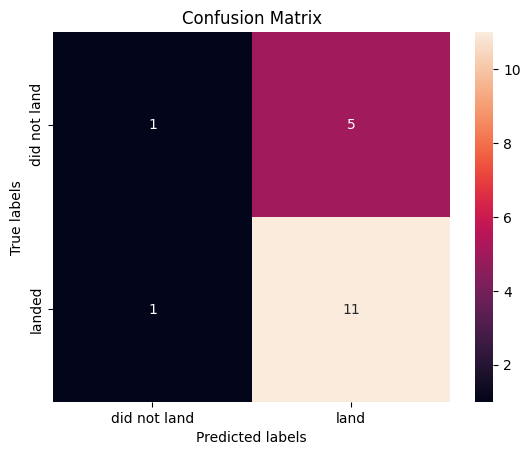

In [22]:
y_predicted = logreg_cv.predict(X_test)

plot_confusion_matrix(Y_test, y_predicted)

In [23]:
parameters = {
    "kernel": ("linear", "rbf", "poly", "rbf", "sigmoid"),
    "C": np.logspace(-3, 3, 5),
    "gamma": np.logspace(-3, 3, 5),
}

svm = SVC()

svm_cv = GridSearchCV(svm, parameters, cv=10)

svm_cv.fit(X_train, Y_train)

print("tuned hyperparameters :(best parameters) ", svm_cv.best_params_)
print("accuracy :", svm_cv.best_score_)

tuned hyperparameters :(best parameters)  {'C': np.float64(1000.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.7553571428571428


In [24]:
svm_cv.score(X_test, Y_test)

0.7777777777777778

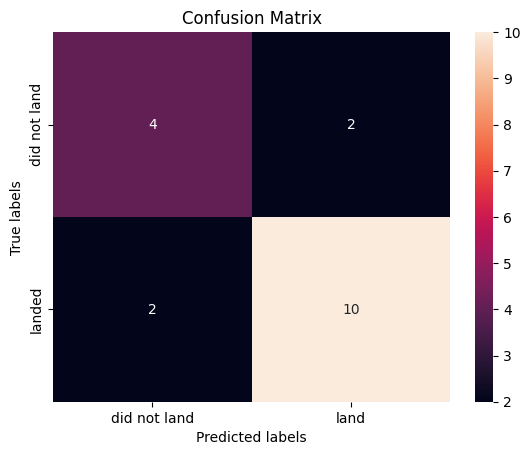

In [25]:
yhat = svm_cv.predict(X_test)

plot_confusion_matrix(Y_test, yhat)

In [27]:
parameters = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [2 * n for n in range(1, 10)],
    "max_features": ["sqrt", "log2"],
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 5, 10],
}
tree = DecisionTreeClassifier()

tree_cv = GridSearchCV(tree, parameters, cv=10)

tree_cv.fit(X_train, Y_train)

print("tuned hyperparameters :(best parameters) ", tree_cv.best_params_)
print("accuracy :", tree_cv.best_score_)

tuned hyperparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'splitter': 'best'}
accuracy : 0.7803571428571427


In [28]:
tree_cv.score(X_test, Y_test)

0.6666666666666666

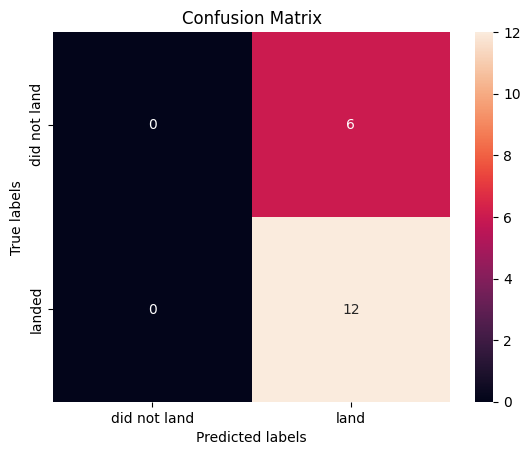

In [29]:
yhat = tree_cv.predict(X_test)

plot_confusion_matrix(Y_test, yhat)

In [30]:
parameters = {
    "n_neighbors": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
    "p": [1, 2],
}

KNN = KNeighborsClassifier()

knn_cv = GridSearchCV(KNN, parameters, cv=10)

knn_cv.fit(X_train, Y_train)

print("tuned hyperparameters :(best parameters) ", knn_cv.best_params_)
print("accuracy :", knn_cv.best_score_)

tuned hyperparameters :(best parameters)  {'algorithm': 'kd_tree', 'n_neighbors': 4, 'p': 1}
accuracy : 0.6821428571428572


In [31]:
knn_cv.score(X_test, Y_test)

0.7222222222222222

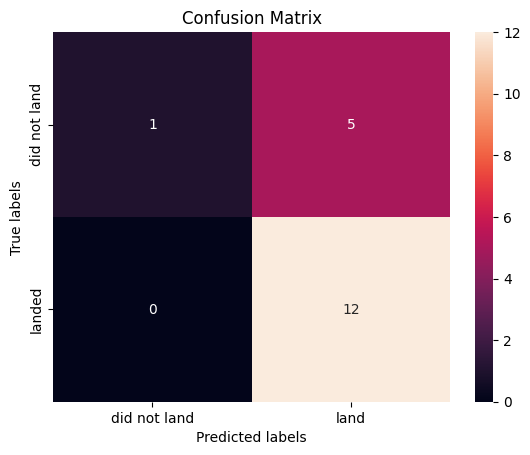

In [32]:
yhat = knn_cv.predict(X_test)

plot_confusion_matrix(Y_test, yhat)

In [34]:
print("Logistic Regression:", (logreg_cv.score(X_test, Y_test)) * 100, "%")
print("SVM:", svm_cv.score(X_test, Y_test) * 100, "%")
print("Decision Tree:", tree_cv.score(X_test, Y_test) * 100, "%")
print("KNN:", knn_cv.score(X_test, Y_test) * 100, "%")

Logistic Regression: 66.66666666666666 %
SVM: 77.77777777777779 %
Decision Tree: 66.66666666666666 %
KNN: 72.22222222222221 %


SVM performs best.